In [26]:
import numpy as np
import chargequbit as cq
import matplotlib.pyplot as plt
import zeroheliumkit as zhk

In [ ]:
help(cq.Resonator)
help(cq.Schrodinger1DSolver)
help(cq.TrapPotential)
help(cq.ChargeQubit)


Help on class Resonator in module chargequbit.electron:

class Resonator(builtins.object)
 |  Resonator(
 |      type: str,
 |      couplings: zeroheliumkit.fem.fieldreader.CouplingConstants,
 |      names: list[str],
 |      resonance_frequency: float,
 |      total_capacitance: float
 |  ) -> None
 |
 |  Resonator(type: str, couplings: zeroheliumkit.fem.fieldreader.CouplingConstants, names: list[str], resonance_frequency: float, total_capacitance: float)
 |
 |  Methods defined here:
 |
 |  __eq__(self, other)
 |      Return self==value.
 |
 |  __init__(
 |      self,
 |      type: str,
 |      couplings: zeroheliumkit.fem.fieldreader.CouplingConstants,
 |      names: list[str],
 |      resonance_frequency: float,
 |      total_capacitance: float
 |  ) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __post_init__(self)
 |
 |  __replace__ = _replace(self, /, **changes) from dataclasses
 |
 |  __repr__(self)
 |      Return repr(self).
 |
 |  get_fie

Zero-point energy:  4.14 µeV
Potential clip:     82.76 µeV
x range:            -8.0 to 8.0 µm

f01 = 0.0000 GHz


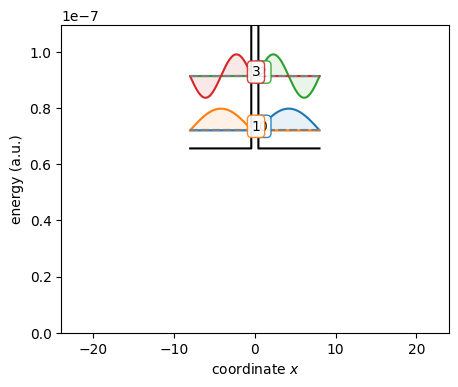

In [18]:
um   = 1e-6
e    = 1.602e-19
m_e  = 9.109e-31

f_target = 2e9
omega    = 2 * np.pi * f_target

# ── Wider grid — give the solver plenty of room ───────────────────────────
N    = 1000
x_um = np.linspace(-8, 8, N)          # µm — passed as-is, x_unit handles scaling
x_m  = x_um * um

# Potential in Volts
V_volts = 0.5 * m_e * omega**2 * x_m**2 / e

# ── Clip the potential — very large walls confuse the mask ────────────────
# The solver's mask likely looks for V < V_min + some_fraction*(V_max-V_min)
# If the walls are enormous the threshold falls outside the grid.
# Clip at a reasonable maximum (e.g. 10x the zero-point energy in eV)
hbar  = 1.055e-34
E_zpe = 0.5 * hbar * omega / e        # zero-point energy in eV
V_clip = 20 * E_zpe                   # clip walls at 20× ZPE
V_volts = np.clip(V_volts, None, V_clip)

print(f"Zero-point energy:  {E_zpe*1e6:.2f} µeV")
print(f"Potential clip:     {V_clip*1e6:.2f} µeV")
print(f"x range:            {x_um.min():.1f} to {x_um.max():.1f} µm")

solver = cq.Schrodinger1DSolver(
    x         = x_um,
    potential = V_volts,
    x_unit    = 1e-6
)

# ── Frequencies ───────────────────────────────────────────────────────────
frequencies = solver.get_frequences(N_evals=6)
print(f"\nf01 = {frequencies[0]/1e9:.4f} GHz")

# ── Plot — should now work ────────────────────────────────────────────────
solver.plot_solution(N_evals=4)
plt.show()

In [17]:
# Constants
hbar  = 1.055e-34   # J·s
m_e   = 9.109e-31   # kg
nm    = 1e-9
um    = 1e-6

# Target frequency
f_target = 2e9                  # Hz
omega    = 2 * np.pi * f_target

# ── Zero-point fluctuation length ─────────────────────────────────────────
x_zpf = np.sqrt(hbar / (2 * m_e * omega))

print(f"Frequency:       {f_target/1e9:.1f} GHz")
print(f"x_zpf:           {x_zpf*1e9:.4f} nm")
print(f"x_zpf:           {x_zpf/um:.6f} µm")

# ── Show how it scales with frequency ─────────────────────────────────────
print(f"\n=== x_zpf vs frequency ===")
for f_ghz in [1, 2, 3, 5, 7, 10]:
    w = 2 * np.pi * f_ghz * 1e9
    xz = np.sqrt(hbar / (2 * m_e * w))
    print(f"  {f_ghz:3d} GHz  →  x_zpf = {xz*1e9:.3f} nm")

Frequency:       2.0 GHz
x_zpf:           67.8846 nm
x_zpf:           0.067885 µm

=== x_zpf vs frequency ===
    1 GHz  →  x_zpf = 96.003 nm
    2 GHz  →  x_zpf = 67.885 nm
    3 GHz  →  x_zpf = 55.428 nm
    5 GHz  →  x_zpf = 42.934 nm
    7 GHz  →  x_zpf = 36.286 nm
   10 GHz  →  x_zpf = 30.359 nm



=== Dipole matrix elements (corrected) ===
⟨0|x̂|1⟩  = 0.1239 nm   (ground → 1st excited)
⟨1|x̂|2⟩  = 0.0369 nm   (1st → 2nd excited)
⟨0|x̂|2⟩  = 1378.147872 nm   (should be ~0 — selection rule)

=== Sanity check ===
x_zpf              = 67.8846 nm
x_zpf / √2         = 48.0016 nm  (analytic ⟨0|x̂|1⟩)
⟨0|x̂|1⟩ numerical  = 0.1239 nm
Discrepancy        = 99.74 %


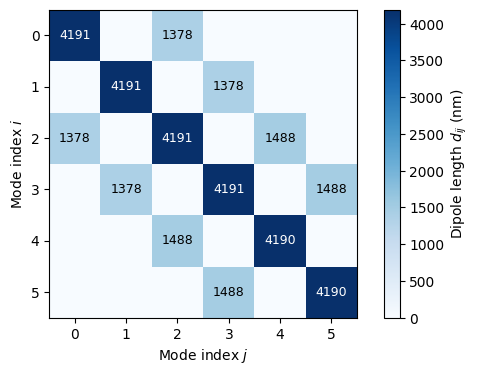

In [25]:
# Constants
hbar   = 1.055e-34
m_e    = 9.109e-31
e      = 1.602e-19
um     = 1e-6
x_unit = 1e-6

f_target = 2e9
omega    = 2 * np.pi * f_target
x_zpf    = np.sqrt(hbar / (2 * m_e * omega))

# Get dipole matrix — returned in µm (solver internal units)
dipole_matrix = solver.get_dipole_length(N_evals=6, plot_result=True)

# Convert to metres
dipole_matrix_m = dipole_matrix * x_unit

# Extract key elements
x_01 = dipole_matrix_m[0, 1]
x_12 = dipole_matrix_m[1, 2]
x_02 = dipole_matrix_m[0, 2]

print(f"\n=== Dipole matrix elements (corrected) ===")
print(f"⟨0|x̂|1⟩  = {x_01*1e9:.4f} nm   (ground → 1st excited)")
print(f"⟨1|x̂|2⟩  = {x_12*1e9:.4f} nm   (1st → 2nd excited)")
print(f"⟨0|x̂|2⟩  = {x_02*1e9:.6f} nm   (should be ~0 — selection rule)")

print(f"\n=== Sanity check ===")
print(f"x_zpf              = {x_zpf*1e9:.4f} nm")
print(f"x_zpf / √2         = {x_zpf/np.sqrt(2)*1e9:.4f} nm  (analytic ⟨0|x̂|1⟩)")
print(f"⟨0|x̂|1⟩ numerical  = {abs(x_01)*1e9:.4f} nm")
print(f"Discrepancy        = {abs(abs(x_01) - x_zpf/np.sqrt(2))/(x_zpf/np.sqrt(2))*100:.2f} %")

In [21]:
# Constants
hbar   = 1.055e-34
m_e    = 9.109e-31
e      = 1.602e-19
um     = 1e-6
x_unit = 1e-6       # ← this was missing

f_target = 2e9
omega    = 2 * np.pi * f_target
x_zpf    = np.sqrt(hbar / (2 * m_e * omega))

# Diagnostic
print(f"solver.x[:5]  = {solver.x[:5]}")
print(f"solver.x[-5:] = {solver.x[-5:]}")

dx_um = solver.x[1] - solver.x[0]
print(f"grid spacing dx = {dx_um:.6f} (solver units)")

evals, evecs = solver.solve_eigenproblem(solver.x, V_volts)

psi0 = evecs[:, 0]
psi1 = evecs[:, 1]

norm = np.sum(np.abs(psi0)**2) * dx_um
print(f"Ground state norm = {norm:.6f}  (should be 1.0)")

x_01_manual_units = np.sum(np.conj(psi0) * solver.x * psi1) * dx_um
print(f"\n⟨0|x̂|1⟩ manual (solver units) = {x_01_manual_units:.6f}")
print(f"⟨0|x̂|1⟩ manual × x_unit (nm)  = {x_01_manual_units * x_unit * 1e9:.4f} nm")
print(f"analytic x_zpf/√2 (nm)         = {x_zpf/np.sqrt(2)*1e9:.4f} nm")

solver.x[:5]  = [-8.         -7.98398398 -7.96796797 -7.95195195 -7.93593594]
solver.x[-5:] = [7.93593594 7.95195195 7.96796797 7.98398398 8.        ]
grid spacing dx = 0.016016 (solver units)
Ground state norm = 0.016018  (should be 1.0)

⟨0|x̂|1⟩ manual (solver units) = -0.046399+0.000000j
⟨0|x̂|1⟩ manual × x_unit (nm)  = -46.3991+0.0000j nm
analytic x_zpf/√2 (nm)         = 48.0016 nm


In [29]:
help(zhk.Rectangle)
help(zhk.HeliumSurfaceFreeFEM)
help(zhk.FieldAnalyzer)
help(zhk.GMSHmaker2D)
help(zhk.CouplingConstants)
help(zhk.PECSettings)

Help on function Rectangle in module zeroheliumkit.src.geometries:

Rectangle(
    width: float,
    height: float,
    location: tuple | shapely.geometry.point.Point = None,
    direction: float = None,
    round_radius: float = None,
    **kwargs
) -> shapely.geometry.polygon.Polygon
    Returns a rectangle Polygon

    Args:
        width (float): width of the rectangle
        height (float): height of the rectangle

    Example:
        >>> Rectangle(4, 2)

Help on class HeliumSurfaceFreeFEM in module zeroheliumkit.fem.heliumsurface:

class HeliumSurfaceFreeFEM(builtins.object)
 |  HeliumSurfaceFreeFEM(fem_config: dict, save_edp: bool = False)
 |
 |  A class to interface with FreeFEM for simulating helium surface displacement using finite element methods (FEM).
 |  This class provides methods to generate FreeFEM scripts, run simulations via pyFreeFem, save scripts to file,
 |  and visualize mesh and results. It is designed to work with mesh files generated by GMSH and supports cus

In [30]:
# import numpy as np
# import matplotlib.pyplot as plt
# import zeroheliumkit as zhk
from zeroheliumkit import (
    Rectangle, Structure, Layer,
    GMSHmaker2D, HeliumSurfaceFreeFEM,
    FieldAnalyzer, CouplingConstants,
    PECSettings, MeshSettings, BoxFieldMeshSettings
)

um = 1e-6
e    = 1.602e-19
m_e  = 9.109e-31
hbar = 1.055e-34

# ── Target ────────────────────────────────────────────────────────────────
f_target = 1e9
omega    = 2 * np.pi * f_target
V_pp_req = m_e * omega**2 / e
print(f"Required V'' = {V_pp_req:.3e} V/m²")

# ══════════════════════════════════════════════════════════════════════════
# STEP 1: Define gate geometry
# All dimensions in µm (zeroheliumkit native units)
# Layout: Barrier_L | 0.5µm gap | Plunger | 0.5µm gap | Barrier_R
# ══════════════════════════════════════════════════════════════════════════
w_P  = 1.0    # plunger width  (µm)
w_B  = 1.0    # barrier width  (µm)
g    = 0.5    # gap            (µm)
h_gate = 0.1  # gate thickness (µm) — thin metal layer

# Gate centre positions (symmetric about x=0)
x_P  = 0.0
x_BL = -(w_P/2 + g + w_B/2)   # barrier L centre
x_BR =  (w_P/2 + g + w_B/2)   # barrier R centre

# Create gate polygons
plunger    = Rectangle(w_P, h_gate, location=(x_P,  0))
barrier_L  = Rectangle(w_B, h_gate, location=(x_BL, 0))
barrier_R  = Rectangle(w_B, h_gate, location=(x_BR, 0))

# ── Assemble into a Structure ─────────────────────────────────────────────
gate_layer = Layer(z=0, thickness=h_gate)   # gates at z=0

layout = Structure()
layout.add(plunger,   layer=gate_layer, name='plunger')
layout.add(barrier_L, layer=gate_layer, name='barrier_L')
layout.add(barrier_R, layer=gate_layer, name='barrier_R')

# Visualise layout
fig, ax = plt.subplots(figsize=(8, 3))
layout.plot(ax=ax)
ax.set_title('Gate layout')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# STEP 2: Configure electrodes (PEC boundaries) and mesh
# ══════════════════════════════════════════════════════════════════════════
electrode_config = {
    'plunger': {
        'layer': ('gate_layer', [0]),   # gate layer, polygon index 0
    },
    'barrier_L': {
        'layer': ('gate_layer', [1]),
    },
    'barrier_R': {
        'layer': ('gate_layer', [2]),
    },
}

# Mesh settings — fine mesh near the trap, coarser far away
domain_size = w_P + 2*g + 2*w_B + 4   # µm — total simulation domain
mesh_config = [
    # Fine mesh box around the trap region
    BoxFieldMeshSettings(
        VIn  = 0.05,    # fine element size (µm) near gates
        VOut = 0.5,     # coarse element size (µm) far away
        Thickness = 0.1,
        box = [-domain_size/2, -1, domain_size/2, 3]  # [xmin, ymin, xmax, ymax]
    ),
]

# Create mesh
mesher = GMSHmaker2D(
    layout         = layout,
    electode_config= electrode_config,
    mesh_config    = mesh_config,
    filename       = 'electron_trap',
    savedir        = './trap_mesh/'
)
mesher.create_geo()
mesher.create_mesh(dim=2)
mesher.finalize()

# ══════════════════════════════════════════════════════════════════════════
# STEP 3: FEM solve — one solve per electrode (coupling constants)
# ══════════════════════════════════════════════════════════════════════════
# HeliumSurfaceFreeFEM solves Laplace equation with helium boundary
# The helium surface is at z = h_He above the gates

h_He_nm = 100    # helium film thickness (nm)
h_He_um = h_He_nm * 1e-3  # µm

fem_config = {
    'meshfile'      : './trap_mesh/electron_trap.msh',
    'electrodes'    : ['plunger', 'barrier_L', 'barrier_R'],
    'helium_level'  : h_He_um,   # He surface height above gates (µm)
    'domain_size'   : domain_size,
}

fem = HeliumSurfaceFreeFEM(fem_config=fem_config, save_edp=True)
fem.create_edp()

# Run one solve per electrode (superposition principle)
# Each solve sets that electrode to 1V, all others to 0V
ff_output = fem.run_pyfreefem()

# ══════════════════════════════════════════════════════════════════════════
# STEP 4: Extract coupling constants and set up FieldAnalyzer
# ══════════════════════════════════════════════════════════════════════════
# CouplingConstants holds the unit-voltage response for each electrode
# on a 2D grid at the helium surface

# The FEM output should give us the potential on a grid
# Parse into CouplingConstants
x_grid = ff_output['x']    # 1D x array (µm)
y_grid = ff_output['y']    # 1D y array (µm)

coupling_data = {
    'plunger'  : ff_output['V_plunger'],    # potential when V_plunger=1V
    'barrier_L': ff_output['V_barrier_L'],
    'barrier_R': ff_output['V_barrier_R'],
}

couplings = CouplingConstants(x=x_grid, y=y_grid, data=coupling_data)

# Create FieldAnalyzer
analyzer = FieldAnalyzer(coupling_constants=couplings)

# ══════════════════════════════════════════════════════════════════════════
# STEP 5: Set voltages and extract curvature → motional frequency
# ══════════════════════════════════════════════════════════════════════════
# Starting voltage guess — will sweep to find 1 GHz
V_P_init = 5e-3    # +5 mV on plunger
V_B_init = -1.5e-3 # -1.5 mV on barriers

analyzer.set_voltages({
    'plunger'  : V_P_init,
    'barrier_L': V_B_init,
    'barrier_R': V_B_init,
})
analyzer.update()

# ── Plot 2D potential ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
analyzer.plot2D_data(ax=axes[0], num_levels=20, zero_line=0)
axes[0].set_title(f'Potential (V_P={V_P_init*1e3:.1f}mV, V_B={V_B_init*1e3:.1f}mV)')

analyzer.plot2D_gradient(grad_axis='x', ax=axes[1], num_levels=20)
axes[1].set_title('E_x = -dV/dx')
plt.tight_layout()
plt.show()

# ── Extract 1D potential slice at electron height ─────────────────────────
# Electron sits ~10nm above He surface → total height = h_He + 10nm
h_electron_um = h_He_um + 0.01   # µm above gates

V_slice = analyzer.get_data(slice=('y', h_electron_um))   # potential along x
x_slice = x_grid

# ── Compute curvature d²V/dx² at trap minimum ────────────────────────────
# Find trap minimum
i_min = np.argmax(V_slice)   # max potential = electron trap (attracted)

# Curvature via finite differences
dx_m = (x_slice[1] - x_slice[0]) * um   # grid spacing in metres
d2V  = (V_slice[i_min+1] - 2*V_slice[i_min] + V_slice[i_min-1]) / dx_m**2

# Motional frequency
f_motional = np.sqrt(abs(e * d2V / m_e)) / (2*np.pi) if d2V > 0 else 0

print(f"\n=== Results for V_P={V_P_init*1e3:.2f}mV, V_B={V_B_init*1e3:.2f}mV ===")
print(f"Trap minimum at x = {x_slice[i_min]:.4f} µm")
print(f"V at minimum      = {V_slice[i_min]*1e6:.4f} µV")
print(f"Curvature d²V/dx² = {d2V:.4e} V/m²")
print(f"f_motional        = {f_motional/1e9:.4f} GHz")
print(f"Target            = {f_target/1e9:.4f} GHz")

# ── Plot 1D potential slice ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
analyzer.plot1D_data(slice=('y', h_electron_um), ax=ax, scale=1e6)
ax.set_xlabel('x (µm)')
ax.set_ylabel('V (µV)')
ax.set_title(f'Potential at electron height ({h_electron_um*1e3:.0f} nm above gates)')
ax.axvline(x_slice[i_min], color='r', ls='--', label='trap minimum')
ax.legend()
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# STEP 6: Voltage sweep to find V_P for exactly 1 GHz
# ══════════════════════════════════════════════════════════════════════════
print("\n=== Voltage sweep to find 1 GHz ===")
print(f"{'V_P (mV)':>12}  {'V_B (mV)':>12}  {'f (GHz)':>12}")
print("-"*40)

def get_freq(V_P, V_B):
    analyzer.set_voltages({
        'plunger'  : V_P,
        'barrier_L': V_B,
        'barrier_R': V_B,
    })
    analyzer.update()
    Vs   = analyzer.get_data(slice=('y', h_electron_um))
    imin = np.argmax(Vs)
    if imin == 0 or imin == len(Vs)-1:
        return 0.0
    d2V  = (Vs[imin+1] - 2*Vs[imin] + Vs[imin-1]) / dx_m**2
    return np.sqrt(abs(e*d2V/m_e))/(2*np.pi) if d2V > 0 else 0.0

# Binary search for V_P that gives 1 GHz (V_B = -0.3 * V_P)
lo, hi = 1e-4, 0.5
for _ in range(30):
    vm = (lo + hi) / 2
    fm = get_freq(vm, -0.3*vm)
    if fm < f_target: lo = vm
    else:             hi = vm

V_P_1GHz = (lo + hi) / 2
V_B_1GHz = -0.3 * V_P_1GHz
f_final   = get_freq(V_P_1GHz, V_B_1GHz)

print(f"{V_P_1GHz*1e3:>12.4f}  {V_B_1GHz*1e3:>12.4f}  {f_final/1e9:>12.4f}")
print(f"\nFinal design:")
print(f"  V_plunger  = +{V_P_1GHz*1e3:.4f} mV")
print(f"  V_barrier  = {V_B_1GHz*1e3:.4f} mV")
print(f"  f_motional = {f_final/1e9:.4f} GHz")

Required V'' = 2.245e+08 V/m²


TypeError: Layer.__init__() got an unexpected keyword argument 'z'

In [ ]:
import pandas as pd

# Example: load a COMSOL export with columns x, y, V
df = pd.read_csv('trap_potential.csv')
x_data = df['x'].values
y_data = df['y'].values
V_data = df['V'].values

# Reshape to 2D grid if needed
N = int(np.sqrt(len(x_data)))
x_1d = np.unique(x_data)
y_1d = np.unique(y_data)
V_2d = V_data.reshape(N, N)

trap = cq.TrapPotential(x=x_1d, y=y_1d, potential=V_2d)